In [2]:
import os
import glob

# 目标文件夹路径
folder_path = "/data/xuzhenhao/StableAnimator/dataset/video"

# 获取所有文件，并按名称排序
files = sorted(glob.glob(os.path.join(folder_path, "*")))

# 遍历文件并重命名
for i, file in enumerate(files):
    folder, old_name = os.path.split(file)
    _, ext = os.path.splitext(old_name)  # 获取后缀
    new_name = f"{i:05d}{ext}"  # 生成形如 00000.后缀 的新文件名
    new_path = os.path.join(folder, new_name)
    os.rename(file, new_path)

print("重命名完成！")


重命名完成！


In [3]:
import os
import shutil
import glob
from tqdm import tqdm

# 源目录（包含 a, b, c, ... g 这些子文件夹）
source_root = "/data/muxiangyu/pythonPrograms/StableAnimator/dataset/centered_heads"
# 目标目录（animation_data 下的 a, b, c, ... g 这些子文件夹）
target_root = "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data"

# 遍历 human_clothes 目录下的子文件夹（a, b, c, ..., g）
for folder in tqdm(os.listdir(source_root)):
    source_folder = os.path.join(source_root, folder)
    target_folder = os.path.join(target_root, folder, "centered_heads")  # 目标 clothes 目录

    # 确保 source_folder 是一个目录
    if os.path.isdir(source_folder):
        if not os.path.exists(target_folder):
            os.makedirs(target_folder)  # 创建目标目录（如果不存在）

        # 遍历该子文件夹中的所有图片
        for img_file in glob.glob(os.path.join(source_folder, "*")):
            shutil.copy2(img_file, target_folder)  # 复制文件（保留元信息）

print("所有图片已成功复制！")


100%|██████████| 600/600 [00:55<00:00, 10.84it/s]

所有图片已成功复制！


In [3]:

import os
import glob
import random

video_dir = "/data/xuzhenhao/StableAnimator/dataset/video"  # 视频所在目录
output_dir = "/data/xuzhenhao/StableAnimator/animation_data"  # 图片输出目录

os.makedirs(output_dir, exist_ok=True)

# 获取所有视频文件
videos = glob.glob(os.path.join(video_dir, "*.mp4"))


# 处理 rec 组
for video in videos:
    file_name = os.path.basename(video)  # 获取文件名（带后缀）
    folder_name = os.path.splitext(file_name)[0]  # 去除后缀，作为文件夹名称
    output_path = os.path.join(output_dir, folder_name, "images")
    os.makedirs(output_path, exist_ok=True)

    cmd = f'ffmpeg -i "{video}" -q:v 1 -start_number 0 "{output_path}/frame_%d.png"'
    os.system(cmd)


ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

In [4]:
import re
from tqdm import tqdm
import os


def rename_filename(filename):
    pattern = r'(\d+)\.png'
    match = re.search(pattern, filename)
    if match:
        number = int(match.group(1))
        new_filename = f'frame_{number}.png'
        return new_filename
    return filename
rootPath = '/data/muxiangyu/pythonPrograms/StableAnimator/animation_data'
for folder in tqdm(os.listdir(rootPath)):
    folderPath = os.path.join(rootPath, folder, 'centered_heads')
    if not os.path.isdir(folderPath):
        continue
    for file in os.listdir(folderPath):
        new_filename = rename_filename(file)
        os.rename(os.path.join(folderPath, file), os.path.join(folderPath, new_filename))

100%|██████████| 601/601 [00:05<00:00, 109.38it/s]


In [12]:
import os
import glob

# 目标根目录
target_root = "/data/xuzhenhao/StableAnimator/animation_data"

# 遍历 animation_data 下的所有子文件夹（a, b, c, ... g）
# for folder in os.listdir(target_root):
    # clothes_folder = os.path.join(target_root, folder, "heads")
# clothes_folder = os.path.join(target_root, "heads")
clothes_folder = "/data/xuzhenhao/StableAnimator/inference/case-21/masks"

# 确保是一个目录
if os.path.isdir(clothes_folder):
    # 获取所有 .png 图片，并按文件名排序
    images = sorted(glob.glob(os.path.join(clothes_folder, "*.png")))

    # 进行重命名
    for index, img_path in enumerate(images):
        new_name = f"frame_{index}.png"  # 目标文件名
        new_path = os.path.join(clothes_folder, new_name)
        os.rename(img_path, new_path)

print("重命名完成！")


重命名完成！


将文件命名为0001、0002.。。

In [2]:
import os
import natsort
import shutil
from tqdm import tqdm

# 目标目录
target_root = "/data/muxiangyu/TryonDatasets/datasets/centered_heads"
target_root_rename = "/data/muxiangyu/pythonPrograms/StableAnimator/dataset/centered_heads"

# 获取所有符合命名规则的文件夹
folders = [f for f in os.listdir(target_root) if os.path.isdir(os.path.join(target_root, f))]

# 按**自然排序**排序文件夹
sorted_folders = natsort.natsorted(folders)

# 依次重命名
for index, old_name in tqdm(enumerate(sorted_folders, start=1)):
    new_name = f"{index:05d}"  # 生成 00001, 00002, ...
    old_path = os.path.join(target_root, old_name)
    new_path = os.path.join(target_root_rename, new_name)
    if not os.path.exists(new_path):
        os.makedirs(new_path)
    # os.rename(old_path, new_path)
    for img in os.listdir(old_path):
        shutil.copy(os.path.join(old_path, img), os.path.join(new_path, img))

print("所有文件夹已按自然排序重命名完成！")


4it [00:00, 34.22it/s]

600it [00:42, 14.28it/s]

所有文件夹已按自然排序重命名完成！


从mask提取衣服区域

In [4]:
import os
import cv2
import numpy as np
def extractClothes(image_path,parse_path,save_path):
    img = cv2.imread(image_path)
    parse = cv2.imread(parse_path,cv2.IMREAD_GRAYSCALE)
    h,w,c = img.shape
    clothes_mask = (parse==12).astype(np.uint8) + (parse==7).astype(np.uint8) + (parse==6).astype(np.uint8)
    # pixels = set()
    # for i in range(h):
    #     for j in range(w):
    #         pixels.add(parse[i,j])
    # print(pixels)
    img = img * clothes_mask[:,:,np.newaxis]
    if not os.path.exists(os.path.dirname(save_path)):
        os.makedirs(os.path.dirname(save_path))
    cv2.imwrite(save_path,img)
    
    

body_images_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/target'
save_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/clothes'
parse_images_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/mask'

# for folder_name in tqdm(os.listdir(body_images_path)):
#     folder_name_path = os.path.join(body_images_path, folder_name)
#     if os.path.isdir(folder_name_path):
for image_name in os.listdir(body_images_path):
    image_path = os.path.join(body_images_path,image_name)
    parse_path = os.path.join(parse_images_path,image_name+'_gray.png')
    save_image_path = os.path.join(save_path,image_name)
    extractClothes(image_path, parse_path, save_image_path)


In [1]:
import os

folder_path = "/data/xuzhenhao/StableAnimator/inference/case-23/images"  # 替换为你的文件夹路径

# 获取所有以 "frame_" 开头的 PNG 文件，并排序
files = sorted([f for f in os.listdir(folder_path) if f.startswith("frame_") and f.endswith(".png")], 
               key=lambda x: int(x.split("_")[1].split(".")[0]))

# 遍历文件并重命名
for i, filename in enumerate(files):
    old_path = os.path.join(folder_path, filename)
    new_filename = f"{i:03d}.png"  # 生成 000.png, 001.png, ...
    new_path = os.path.join(folder_path, new_filename)
    os.rename(old_path, new_path)

print("重命名完成！")


重命名完成！


In [10]:
def extractClothes(image_path,parse_path,save_path):
    img = cv2.imread(image_path)
    parse = cv2.imread(parse_path,cv2.IMREAD_GRAYSCALE)
    h,w,c = img.shape
    clothes_mask = (parse==12).astype(np.uint8) + (parse==7).astype(np.uint8) + (parse==6).astype(np.uint8)
    # pixels = set()
    # for i in range(h):
    #     for j in range(w):
    #         pixels.add(parse[i,j])
    # print(pixels)
    img = img * clothes_mask[:,:,np.newaxis]
    if not os.path.exists(os.path.dirname(save_path)):
        os.makedirs(os.path.dirname(save_path))
    cv2.imwrite(save_path,img)
    
    

body_images_path = '/data/xuzhenhao/StableAnimator/inference/case-23/test_images'
save_path = '/data/xuzhenhao/StableAnimator/inference/case-23/test_clothes1'
parse_images_path = '/data/xuzhenhao/StableAnimator/inference/case-23/test_mask'

# for folder_name in tqdm(os.listdir(body_images_path)):
#     folder_name_path = os.path.join(body_images_path, folder_name)
#     if os.path.isdir(folder_name_path):
#         for image_name in os.listdir(folder_name_path):
#             image_path = os.path.join(folder_name_path,image_name)
#             parse_path = os.path.join(parse_images_path,folder_name,image_name+'_gray.png')
#             save_image_path = os.path.join(save_path,folder_name,image_name)
#             extractClothes(image_path, parse_path, save_image_path)
for image_name in os.listdir(body_images_path):
    image_path = os.path.join(body_images_path, image_name)
    parse_path = os.path.join(parse_images_path,image_name + '_gray.png')
    save_image_path = os.path.join(save_path,image_name)
    extractClothes(image_path, parse_path, save_image_path)

In [25]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def extractClothes(image_path, parse_path, save_path):
    img = cv2.imread(image_path)
    parse = cv2.imread(parse_path, cv2.IMREAD_GRAYSCALE)

    # 创建与原图相同大小的掩码
    #保留衣服
    # clothes_mask = (parse == 1) | (parse == 2) | (parse == 3) | (parse == 4) | (parse == 5) | (parse == 8)| (parse == 9) | (parse == 10) | (parse == 11) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    clothes_mask = (parse == 1) | (parse == 2) | (parse == 3) | (parse == 10) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    #人偶模特
    # clothes_mask = (parse == 0) | (parse == 1) | (parse == 2) | (parse == 3) | (parse == 10) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    #保留头部
    # clothes_mask = (parse == 1) | (parse == 3) | (parse == 4) | (parse == 5) | (parse == 6) | (parse == 7) | (parse == 8)| (parse == 9) | (parse == 10) | (parse == 11) | (parse == 12) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17) | (parse == 18) | (parse == 19)

    # 将掩码区域改为白色
    img[clothes_mask] = [255, 255, 255]

    # # 创建保存目录
    # os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # 保存修改后的图片
    cv2.imwrite(save_path, img)

body_images_path = '/data/xuzhenhao/StableAnimator/animation_data'
save_path = '/data/xuzhenhao/StableAnimator/animation_data'
parse_images_path = '/data/xuzhenhao/StableAnimator/dataset/humanParsing_512_rename'

for folder_name in tqdm(os.listdir(body_images_path)):
    folder_name_path = os.path.join(body_images_path, folder_name, 'images')
    if os.path.isdir(folder_name_path):
        for image_name in os.listdir(folder_name_path):
            image_path = os.path.join(folder_name_path, image_name)
            parse_path = os.path.join(parse_images_path, folder_name, image_name)
            os.makedirs(os.path.join(save_path, folder_name,'clothes_white'), exist_ok=True)
            save_image_path = os.path.join(save_path, folder_name, 'clothes_white', image_name)
            extractClothes(image_path, parse_path, save_image_path)
# for image_name in os.listdir(body_images_path):
#     image_path = os.path.join(body_images_path, image_name)
#     parse_path = os.path.join(parse_images_path,image_name + '_gray.png')
#     save_image_path = os.path.join(save_path,image_name)
#     extractClothes(image_path, parse_path, save_image_path)

100%|██████████| 601/601 [42:43<00:00,  4.27s/it] 


In [24]:
import os
import natsort

# 源文件夹
folder_path = "/data/xuzhenhao/StableAnimator/dataset/humanParsing_512_rename"
for folder in os.listdir(folder_path):
    # 获取所有符合 `_gray.png` 命名规则的文件
    files = [f for f in os.listdir(os.path.join(folder_path,folder)) if f.endswith('_gray.png')]

    # 按自然排序进行排序
    sorted_files = natsort.natsorted(files)

    # 依次重命名为 frame_0.png, frame_1.png, ...
    for index, old_name in enumerate(sorted_files):
        old_path = os.path.join(folder_path, folder, old_name)
        new_name = f"frame_{index}.png"
        new_path = os.path.join(folder_path, folder, new_name)

        os.rename(old_path, new_path)

print("所有文件已按序重命名完成！")


所有文件已按序重命名完成！


In [2]:
import os
import natsort
import shutil

# mp4 文件所在目录
video_dir = "/data/xuzhenhao/StableAnimator/dataset/video"
out = "/data/xuzhenhao/StableAnimator/animation_data/images"

# 获取所有 .mp4 文件，并按 **自然排序** 排序
mp4_files = [f for f in os.listdir(video_dir) if f.endswith(".mp4")]
mp4_files_sorted = natsort.natsorted(mp4_files)

# 依次重命名
for index, old_name in enumerate(mp4_files_sorted, start=1):
    new_name = f"{index:05d}.mp4"  # 生成 00001.mp4, 00002.mp4, ...
    old_path = os.path.join(video_dir, old_name)
    new_path = os.path.join(out, new_name)
    shutil.copy(old_path, new_path)
print("所有视频已按自然排序重命名完成！")


所有视频已按自然排序重命名完成！


In [4]:
import shutil
shutil.move("/data/xuzhenhao/StableAnimator/animation_data/clothes","/data/xuzhenhao/StableAnimator/dataset/train")

'/data/xuzhenhao/StableAnimator/dataset/train/clothes'

In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def extractClothes(image_path, parse_path, save_path):
    img = cv2.imread(image_path)
    parse = cv2.imread(parse_path, cv2.IMREAD_GRAYSCALE)

    # 创建与原图相同大小的掩码
    #保留衣服
    # clothes_mask = (parse == 1) | (parse == 2) | (parse == 3) | (parse == 4) | (parse == 5) | (parse == 8)| (parse == 9) | (parse == 10) | (parse == 11) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    clothes_mask = (parse == 0) | (parse == 1) | (parse == 2) | (parse == 3) | (parse == 10) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    #人偶模特
    # clothes_mask = (parse == 1) | (parse == 2) | (parse == 3) | (parse == 10) | (parse == 13) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17)
    #保留头部
    # clothes_mask =(parse==0) | (parse == 1) | (parse == 3) | (parse == 4) | (parse == 5) | (parse == 6) | (parse == 7) | (parse == 8)| (parse == 9) | (parse == 10) | (parse == 11) | (parse == 12) | (parse == 14) | (parse == 15) | (parse == 16) | (parse == 17) | (parse == 18) | (parse == 19)
    # clothes_mask1 = (parse == 0)
    # 将掩码区域改为白色
    img[clothes_mask] = [255, 255, 255]
    # img[clothes_mask1] = [251, 253, 250]

    # # 创建保存目录
    # os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # 保存修改后的图片
    cv2.imwrite(save_path, img)

body_images_path = '/data/xuzhenhao/StableAnimator/animation_data'
save_path = '/data/xuzhenhao/StableAnimator/animation_data'
parse_images_path = '/data/xuzhenhao/StableAnimator/dataset/humanParsing_512_rename'

for folder_name in tqdm(os.listdir(body_images_path)):
    folder_name_path = os.path.join(body_images_path, folder_name, 'images')
    if os.path.isdir(folder_name_path):
        for image_name in os.listdir(folder_name_path):
            image_path = os.path.join(folder_name_path, image_name)
            parse_path = os.path.join(parse_images_path, folder_name, image_name)
            os.makedirs(os.path.join(save_path, folder_name,'clothes_white_complete'), exist_ok=True)
            save_image_path = os.path.join(save_path, folder_name, 'clothes_white_complete', image_name)
            extractClothes(image_path, parse_path, save_image_path)
# for image_name in os.listdir(body_images_path):
#     image_path = os.path.join(body_images_path, image_name)
#     parse_path = os.path.join(parse_images_path,image_name + '_gray.png')
#     save_image_path = os.path.join(save_path,image_name)
#     extractClothes(image_path, parse_path, save_image_path)

100%|██████████| 601/601 [1:04:39<00:00,  6.46s/it]


In [2]:
import os
import cv2

# 输入和输出文件夹
input_folder = "/data/xuzhenhao/StableAnimator/inference/case-26/poses_100"
output_folder = "/data/xuzhenhao/StableAnimator/inference/case-26/poses"
target_size = (512, 512)  # 指定目标尺寸 (宽, 高)

# 确保输出文件夹存在
os.makedirs(output_folder, exist_ok=True)

# 遍历文件夹中的所有图片
for filename in os.listdir(input_folder):
    img_path = os.path.join(input_folder, filename)
    if os.path.isfile(img_path):
        img = cv2.imread(img_path)
        if img is not None:
            resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
            cv2.imwrite(os.path.join(output_folder, filename), resized_img)

print("图片调整大小完成！")


图片调整大小完成！


In [5]:
def extractClothes(image_path,parse_path,save_path):
    img = cv2.imread(image_path)
    parse = cv2.imread(parse_path,cv2.IMREAD_GRAYSCALE)
    h,w,c = img.shape
    clothes_mask = (parse==12).astype(np.uint8) + (parse==7).astype(np.uint8) + (parse==6).astype(np.uint8) + (parse==11).astype(np.uint8) + (parse==4).astype(np.uint8) + (parse==5).astype(np.uint8) + (parse==8).astype(np.uint8) + (parse==9).astype(np.uint8)
    # pixels = set()
    # for i in range(h):
    #     for j in range(w):
    #         pixels.add(parse[i,j])
    # print(pixels)
    img = img * clothes_mask[:,:,np.newaxis]
    if not os.path.exists(os.path.dirname(save_path)):
        os.makedirs(os.path.dirname(save_path))
    cv2.imwrite(save_path,img)
    
    

body_images_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/target'
save_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/clothes_black'
parse_images_path = '/data/xuzhenhao/StableAnimator/inference/case-22-renou/mask'

# for folder_name in tqdm(os.listdir(body_images_path)):
#     folder_name_path = os.path.join(body_images_path, folder_name)
#     if os.path.isdir(folder_name_path):
for image_name in os.listdir(body_images_path):
    image_path = os.path.join(body_images_path,image_name)
    parse_path = os.path.join(parse_images_path,image_name+'_gray.png')
    save_image_path = os.path.join(save_path,image_name)
    extractClothes(image_path, parse_path, save_image_path)


In [11]:
from PIL import Image

def print_top_left_pixel_value(image_path):
    # 打开图片
    image = Image.open(image_path)
    # 获取图片的宽度和高度
    width, height = image.size
    # 获取最左上角像素点的坐标
    x, y = 0, 0
    # 获取最左上角像素点的像素值
    pixel_value = image.getpixel((x, y))
    print(f"最左上角像素点的像素值: {pixel_value}")

if __name__ == "__main__":
    image_path = "/data/xuzhenhao/StableAnimator/inference/case-28/clothes_white/frame_0.png"  # 替换为你的图片路径
    print_top_left_pixel_value(image_path)

最左上角像素点的像素值: (251, 253, 250)


In [2]:
from PIL import Image
import os

def crop_images(input_folder, output_folder):
    # 检查输出文件夹是否存在，如果不存在则创建
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 遍历输入文件夹中的所有文件
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            # 构建图片文件的完整路径
            input_path = os.path.join(input_folder, filename)
            # 构建输出图片文件的完整路径
            output_path = os.path.join(output_folder, filename)

            try:
                # 打开图片
                image = Image.open(input_path)
                # 获取图片的宽度和高度
                width, height = image.size

                # 计算裁剪区域的坐标
                left = 32
                right = width - 32
                top = 45
                bottom = 557

                # 裁剪图片
                cropped_image = image.crop((left, top, right, bottom))

                # 保存裁剪后的图片
                cropped_image.save(output_path)
                print(f"已裁剪并保存: {filename}")
            except Exception as e:
                print(f"处理 {filename} 时出错: {e}")

if __name__ == "__main__":
    input_folder = "/data/xuzhenhao/StableAnimator/inference/case-22-renou/target_white_background1"  # 替换为实际的输入文件夹路径
    output_folder = "/data/xuzhenhao/StableAnimator/inference/case-22-renou/target_white_background_512"  # 替换为实际的输出文件夹路径
    crop_images(input_folder, output_folder)

已裁剪并保存: frame_14.png
已裁剪并保存: frame_16.png
已裁剪并保存: frame_3.png
已裁剪并保存: frame_4.png
已裁剪并保存: frame_11.png
已裁剪并保存: frame_12.png
已裁剪并保存: frame_0.png
已裁剪并保存: frame_7.png
已裁剪并保存: frame_9.png
已裁剪并保存: frame_18.png
已裁剪并保存: frame_8.png
已裁剪并保存: frame_15.png
已裁剪并保存: frame_19.png
已裁剪并保存: frame_1.png
已裁剪并保存: frame_17.png
已裁剪并保存: frame_20.png
已裁剪并保存: frame_6.png
已裁剪并保存: frame_5.png
已裁剪并保存: frame_13.png
已裁剪并保存: frame_10.png
已裁剪并保存: frame_2.png


In [ ]:
import os
import subprocess

# 图片所在的主目录（包含多个子文件夹，每个子文件夹对应一个视频）
root_dir = "/data/xuzhenhao/StableAnimator/animation_data"
output_dir = "/data/xuzhenhao/StableAnimator/animation_data/poses"

# 确保输出目录存在
os.makedirs(output_dir, exist_ok=True)

# 遍历所有子文件夹
for folder_name in sorted(os.listdir(root_dir)):  # 确保顺序
    folder_path = os.path.join(root_dir, folder_name)
    
    # 确保是目录
    if os.path.isdir(folder_path):
        output_video = os.path.join(output_dir, f"{folder_name}.mp4")  # 输出视频名
        
        # 构造 ffmpeg 命令
        cmd = [
            "ffmpeg", "-framerate", "25", "-i", os.path.join(folder_path,"poses", "frame_%d.png"),
            "-c:v", "libx264", "-crf", "10", "-pix_fmt", "yuv420p", output_video
        ]
        
        # 执行 ffmpeg 命令
        subprocess.run(cmd, check=True)
        print(f"Converted {folder_name} to {output_video}")

print("所有视频转换完成！")


查看图像形状

In [10]:
from PIL import Image

# 读取图像
image_path = "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00454/headMask/frame_1.png"  # 替换为你的图像路径
try:
    image = Image.open(image_path)
    print(f"图像的形状: {image.size}")  # 输出图像的宽和高
except Exception as e:
    print(f"无法读取图像，请检查路径是否正确。错误: {e}")

# 统计image具有哪些像素值
unique_pixels = set(image.getdata())
print(f"图像的唯一像素值: {unique_pixels}")

# 查看image的第一个像素值
first_pixel = image.getpixel((0, 0))
print(f"图像的第一个像素值: {first_pixel}")


图像的形状: (256, 512)
图像的唯一像素值: {0, 255}
图像的第一个像素值: 0


扩充后矩形的左上坐标: (85, 15), 右下坐标: (180, 150)


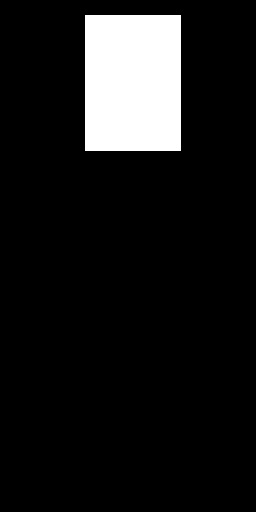

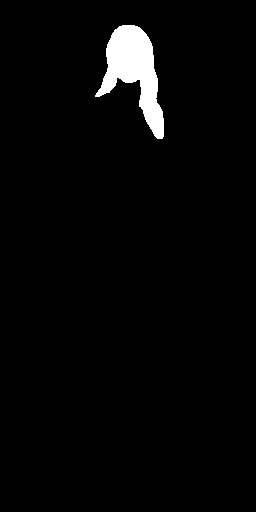

In [14]:
def expand_mask_to_rectangle_with_margin(image, margin=10):
    """
    将指定 mask 图像中的 mask 区域（像素为 255）扩展为一个矩形，并在上下左右边界扩充指定的像素点。
    同时确保扩充后的矩形区域的长宽能够被 8 整除。

    Args:
        image (PIL.Image.Image): 输入的 mask 图像。
        margin (int): 上下左右边界扩充的像素点数。

    Returns:
        tuple: 扩充后的图像和矩形的左上、右下坐标。
    """
    # 转换为灰度图像（确保是单通道）
    mask = image.convert("L")
    pixels = mask.load()

    # 获取图像的宽度和高度
    width, height = mask.size

    # 找到 mask 区域的边界
    min_x, min_y, max_x, max_y = width, height, 0, 0
    for y in range(height):
        for x in range(width):
            if pixels[x, y] == 255:  # 如果像素值为 255
                min_x = min(min_x, x)
                min_y = min(min_y, y)
                max_x = max(max_x, x)
                max_y = max(max_y, y)

    # 如果没有找到 mask 区域，直接返回原图
    if min_x > max_x or min_y > max_y:
        return image, (None, None)

    # 在边界上扩充指定的像素点数
    min_x = max(0, min_x - margin)
    min_y = max(0, min_y - margin)
    max_x = min(width - 1, max_x + margin)
    max_y = min(height - 1, max_y + margin)

    # 确保扩充后的矩形区域的长宽能够被 8 整除
    rect_width = max_x - min_x + 1
    rect_height = max_y - min_y + 1

    if rect_width % 8 != 0:
        max_x = min(width - 1, max_x + (8 - rect_width % 8))
    if rect_height % 8 != 0:
        max_y = min(height - 1, max_y + (8 - rect_height % 8))

    # 创建一个新的图像，并绘制扩展后的矩形
    expanded_image = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(expanded_image)
    draw.rectangle([min_x, min_y, max_x, max_y], fill=255)

    return expanded_image, ((min_x, min_y), (max_x, max_y))

# 使用示例
expanded_image_with_margin, rectangle_coords = expand_mask_to_rectangle_with_margin(image, margin=10)
print(f"扩充后矩形的左上坐标: {rectangle_coords[0]}, 右下坐标: {rectangle_coords[1]}")
expanded_image_with_margin.show()  # 显示扩充后的图像
image.show()  # 显示原始图像


扩充后的矩形坐标: (109, 9, 183, 78)
扩充后的 tensor 形状: torch.Size([1, 5, 1, 512, 256])


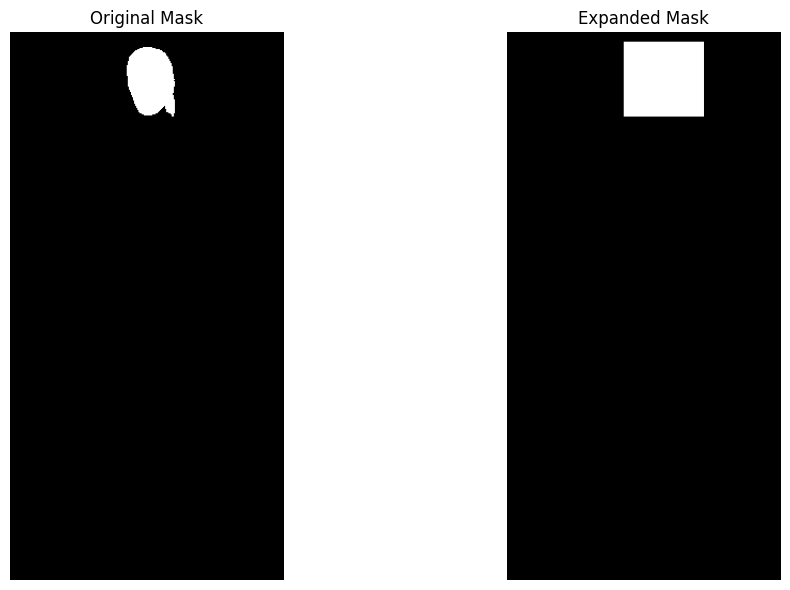

expanded_tensor shape: torch.Size([1, 5, 1, 512, 256])
Mask shape: torch.Size([1, 512, 256])
保存图像: /data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images/masked_image_1.png
Mask shape: torch.Size([1, 512, 256])
保存图像: /data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images/masked_image_2.png
Mask shape: torch.Size([1, 512, 256])
保存图像: /data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images/masked_image_3.png
Mask shape: torch.Size([1, 512, 256])
保存图像: /data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images/masked_image_4.png
Mask shape: torch.Size([1, 512, 256])
保存图像: /data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images/masked_image_5.png


In [15]:
import torch
from PIL import Image, ImageDraw
import numpy as np
import os
import glob

def create_tensor_from_masks(image_paths):
    """
    将指定的 mask 图片拼成一个形状为 (batch, frame, c, h, w) 的 tensor。
    """
    images = [Image.open(path).convert("L") for path in image_paths]
    h, w = images[0].size
    tensor = torch.zeros((1, len(images), 1, w, h), dtype=torch.uint8)

    for i, img in enumerate(images):
        tensor[0, i, 0] = torch.from_numpy(np.array(img))

    return tensor

def find_and_expand_masks(tensor):
    """
    根据 tensor 中的 mask 区域，找到每个 mask 的最左上和最右下坐标，
    并将所有 mask 扩充为符合最左上和最右下的矩形。
    """
    batch, frames, c, h, w = tensor.shape
    assert batch == 1 and c == 1, "Batch size and channel size must be 1."

    tensor = tensor.clone()  # 防止修改原始 tensor
    min_x, min_y, max_x, max_y = w, h, 0, 0

    # 找到所有 mask 的最左上和最右下坐标
    for frame in range(frames):
        mask = tensor[0, frame, 0]
        coords = torch.nonzero(mask == 255, as_tuple=False)
        if coords.numel() > 0:
            min_x = min(min_x, coords[:, 1].min().item())
            min_y = min(min_y, coords[:, 0].min().item())
            max_x = max(max_x, coords[:, 1].max().item())
            max_y = max(max_y, coords[:, 0].max().item())

    # 扩充所有 mask 为矩形
    for frame in range(frames):
        mask = tensor[0, frame, 0]
        mask[:, :] = 0  # 清空原始 mask
        mask[min_y:max_y+1, min_x:max_x+1] = 255  # 填充矩形区域

    return tensor, (min_x, min_y, max_x, max_y)

# 示例用法
image_paths = [
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/headMask/frame_31.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/headMask/frame_61.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/headMask/frame_91.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/headMask/frame_121.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/headMask/frame_151.png"
]

tensor = create_tensor_from_masks(image_paths)
expanded_tensor, rectangle_coords = find_and_expand_masks(tensor)

print(f"扩充后的矩形坐标: {rectangle_coords}")
print(f"扩充后的 tensor 形状: {expanded_tensor.shape}")
import matplotlib.pyplot as plt

# 展示原始 mask 图和扩充后的 mask 图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 原始 mask 图
original_mask = Image.open(image_paths[2]).convert("L")
axes[0].imshow(original_mask, cmap="gray")
axes[0].set_title("Original Mask")
axes[0].axis("off")

# 扩充后的 mask 图
expanded_mask = expanded_tensor[0, 2, 0].numpy()
axes[1].imshow(expanded_mask, cmap="gray")
axes[1].set_title("Expanded Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

def apply_mask_and_save_images(expanded_tensor, image_paths, output_folder):
    """
    将扩展后的 mask 与指定的图像相乘，并剪切出 mask 的区域，保存结果图像。
    """
    os.makedirs(output_folder, exist_ok=True)
    print('expanded_tensor shape:',expanded_tensor.shape)

    for i, image_path in enumerate(image_paths):
        # 读取原始图像
        image = Image.open(image_path).convert("RGB")
        image_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1)  # 转换为 (C, H, W)

        # 获取扩展后的 mask
        mask = expanded_tensor[0, i, 0]  # 保持为 tensor 类型
        mask = mask.unsqueeze(0)  # 添加一个通道维度，形状变为 (1, H, W)
        print(f"Mask shape: {mask.shape}")
        # 将mask进行归一化处理
        mask = mask / 255.0

        # 应用 mask
        masked_image = image_tensor * mask  # 广播相乘，形状为 (C, H, W)

        # 找到 mask 的边界
        coords = torch.nonzero(mask[0] > 0, as_tuple=False)
        if coords.size(0) > 0:
            y_min, x_min = coords.min(dim=0).values
            y_max, x_max = coords.max(dim=0).values

            # 剪切出 mask 的区域
            cropped_image = masked_image[:, y_min:y_max+1, x_min:x_max+1]

            # 保存结果图像
            cropped_image = cropped_image.permute(1, 2, 0).byte().numpy()  # 转换为 (H, W, C)
            output_path = os.path.join(output_folder, f"masked_image_{i+1}.png")
            Image.fromarray(cropped_image).save(output_path)
            print(f"保存图像: {output_path}")
        else:
            print(f"跳过图像 {image_path}，因为 mask 区域为空。")

# 示例用法
output_folder = "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/masked_images"
image_paths_1 = [
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/images/frame_31.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/images/frame_61.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/images/frame_91.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/images/frame_121.png",
    "/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_512_256/00001/images/frame_151.png"
]

apply_mask_and_save_images(expanded_tensor, image_paths_1, output_folder)


In [19]:
def find_mask_coordinates(tensor):
    """
    识别 expanded_tensor 中 mask 区域（像素值为 1）的左上和右下坐标。

    Args:
        tensor (torch.Tensor): 输入的 tensor，形状为 (batch, frames, c, h, w)。

    Returns:
        list: 每一帧的左上和右下坐标，格式为 [(min_x, min_y, max_x, max_y), ...]。
    """
    batch, frames, c, h, w = tensor.shape
    assert batch == 1 and c == 1, "Batch size and channel size must be 1."

    coordinates = []
    # 输出tensor具有哪些像素值
    unique_values = torch.unique(tensor)
    print("Unique values in the tensor:", unique_values)

    for frame in range(frames):
        mask = tensor[0, frame, 0]  # 提取单帧 mask
        coords = torch.nonzero(mask == 255, as_tuple=False)  # 找到 mask 区域的坐标
        if coords.numel() > 0:
            min_y, min_x = coords.min(dim=0).values.tolist()
            max_y, max_x = coords.max(dim=0).values.tolist()
            coordinates.append((min_x, min_y, max_x, max_y))
        else:
            coordinates.append(None)  # 如果没有 mask 区域，返回 None

    return coordinates

# 示例用法
mask_coordinates = find_mask_coordinates(expanded_tensor)
print(mask_coordinates)

Unique values in the tensor: tensor([  0, 255], dtype=torch.uint8)
[(109, 9, 183, 78), (109, 9, 183, 78), (109, 9, 183, 78), (109, 9, 183, 78), (109, 9, 183, 78)]


In [ ]:
import os
from collections import defaultdict

# Paths
root_folder = '/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/video600_256_128'
output_txt_path = '/data/muxiangyu/pythonPrograms/StableAnimator/animation_data/differences.txt'

# Function to get all filenames (without extension) from a directory
def get_filenames_without_ext(directory):
    if not os.path.exists(directory):
        return set()
    return {os.path.splitext(file)[0] for file in os.listdir(directory) if os.path.isfile(os.path.join(directory, file))}

# Open the output file
with open(output_txt_path, 'w') as output_file:
    # Iterate through first-level subdirectories
    for first_level_dir in os.listdir(root_folder):
        first_level_path = os.path.join(root_folder, first_level_dir)
        
        if not os.path.isdir(first_level_path):
            continue
        
        # Get path to the 'images' directory
        images_dir = os.path.join(first_level_path, 'headMask')
        if not os.path.exists(images_dir):
            output_file.write(f"WARNING: No 'images' directory found in {first_level_path}\n")
            continue
        
        # Get all image filenames (without extension)
        image_filenames = get_filenames_without_ext(images_dir)
   
        
        # Iterate through second-level subdirectories (excluding 'images')
        for second_level_dir in os.listdir(first_level_path):
            second_level_path = os.path.join(first_level_path, second_level_dir)
            
            # if not os.path.isdir(second_level_path) or second_level_dir == 'headMask':
            #     continue
            
            # Get filenames in this subdirectory
            subdir_filenames = get_filenames_without_ext(second_level_path)
        
            # Check if counts match
            if len(image_filenames) != len(subdir_filenames):
                output_file.write(f"Mismatch in {first_level_dir}/{second_level_dir}: " 
                                  f"{len(subdir_filenames)} files vs {len(image_filenames)} in headMask\n")
                print(f"Mismatch in {first_level_dir}/{second_level_dir}: " 
                                  f"{len(subdir_filenames)} files vs {len(image_filenames)} in headMask\n")

                
                # Find missing files
                missing_in_images = subdir_filenames - image_filenames
                missing_in_subdir = image_filenames - subdir_filenames
                
                if missing_in_images:
                    output_file.write(f"  Files in {second_level_dir} but not in images: {', '.join(sorted(missing_in_images))}\n")
                
                if missing_in_subdir:
                    output_file.write(f"  Files in images but not in {second_level_dir}: {', '.join(sorted(missing_in_subdir))}\n")

print(f"Analysis complete. Results written to {output_txt_path}")

Both folders have the same number of files: 243


True